# Simulating CEX chromatography

## Importing libraries

numpy: Used for numerical operations.
matplotlib: Used for plotting simulation results.
CADETProcess: A library for chromatography simulations.


In [1]:
import numpy as np


import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches


from CADETProcess.simulator import Cadet
from calibration_LGE import generate_flowsheet, generate_process

## Plotting function
Define a function for plotting simulation results

In [2]:
def plot_sim_results(simulation_results):
    c_out = simulation_results.solution.outlet.outlet.solution
    t_out = simulation_results.solution.outlet.outlet.time
    
    plt.plot(t_out/60, c_out[:, 0], lw=1.5, c='k', alpha=0.5)
    plt.plot(t_out/60, c_out[:, 1:]*1e4, lw=1.5, c='b', alpha=0.5)
    
    plt.xlabel('Time [min]')
    plt.ylabel('Salt concentration [mM]\nProtein concentration [1e4 *mM]')



## Simulation

Run multiple simulation with different gradient lengths.

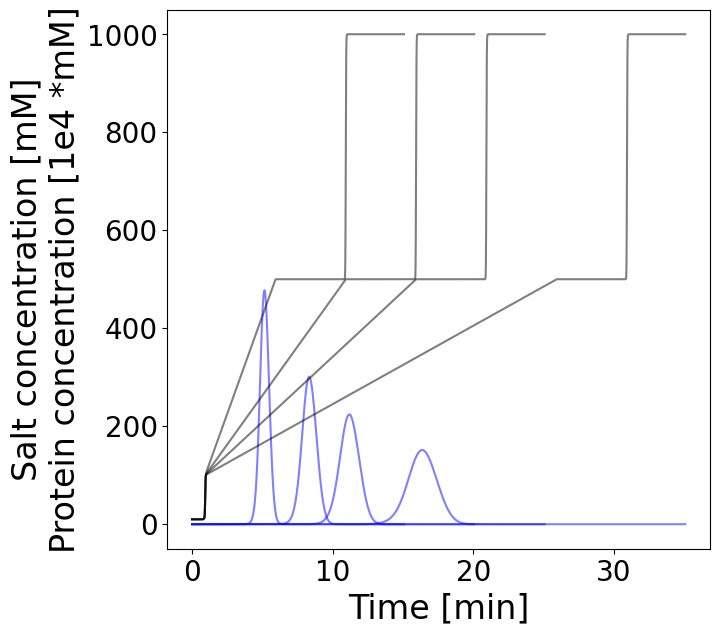

In [4]:
from calibration_LGE import generate_flowsheet, generate_process

flowsheet = generate_flowsheet()
simulator = Cadet()
# assign variables for optimization
flowsheet.column.binding_model.characteristic_charge = [1, 6]
flowsheet.column.binding_model.adsorption_rate = [1, 1307]
flowsheet.column.binding_model.steric_factor = [0, 0]
flowsheet.column.film_diffusion = [1e-3, 1e-5]

gradients = [5, 10, 15, 25]
peak_salt = {}

plt.figure(figsize=(7,7))
for gradient in gradients:
    process = generate_process(flowsheet, gradient)
    sim_results = simulator.simulate(process)
    plot_sim_results(sim_results)
    c_out = sim_results.solution.outlet.outlet.solution
    peak_salt[gradient] = c_out[np.argmax(c_out[:, 1]), 0]

## Exercises
1. Why is the protein concentration multiplied by 1e4 in the plot?
2. How does the retention time change if the gradient becomes longer?
3. Run your own simulations with varying characteristic charges (between 5 and 7)